In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/datasets/mukeshdevrath007/indian-5000-cities-weather-data/w_d_2/Kurtkoti.csv
/kaggle/input/datasets/mukeshdevrath007/indian-5000-cities-weather-data/w_d_2/Mohanpur.csv
/kaggle/input/datasets/mukeshdevrath007/indian-5000-cities-weather-data/w_d_2/Jaipur_2.csv
/kaggle/input/datasets/mukeshdevrath007/indian-5000-cities-weather-data/w_d_2/Hardia_2.csv
/kaggle/input/datasets/mukeshdevrath007/indian-5000-cities-weather-data/w_d_2/Jogbani.csv
/kaggle/input/datasets/mukeshdevrath007/indian-5000-cities-weather-data/w_d_2/Lakhipur_3.csv
/kaggle/input/datasets/mukeshdevrath007/indian-5000-cities-weather-data/w_d_2/Madakasira.csv
/kaggle/input/datasets/mukeshdevrath007/indian-5000-cities-weather-data/w_d_2/Khair Khan.csv
/kaggle/input/datasets/mukeshdevrath007/indian-5000-cities-weather-data/w_d_2/Kochi.csv
/kaggle/input/datasets/mukeshdevrath007/indian-5000-cities-weather-data/w_d_2/Nanjanad.csv
/kaggle/input/datasets/mukeshdevrath007/indian-5000-cities-weather-data/w_d_2/Kokiladang

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings, glob, random
from pathlib import Path

warnings.filterwarnings("ignore")
plt.rcParams["figure.figsize"] = (12, 5)
plt.rcParams["axes.titlesize"] = 13
plt.rcParams["axes.titleweight"] = "bold"
sns.set_style("whitegrid")
pd.set_option("display.max_columns", 50)
pd.set_option("display.width", 140)

# ---------------------------------------------------------------
# PATH CONFIG -- auto-detects Kaggle input path so you don't need to
# hardcode the dataset slug. Falls back to local paths if not on Kaggle.
# ---------------------------------------------------------------
def _find_kaggle_data_root():
    # Known exact path for this dataset -- checked first
    explicit_path = Path("/kaggle/input/datasets/mukeshdevrath007/indian-5000-cities-weather-data")
    if (explicit_path / "w_d_1").exists():
        return explicit_path
    # Fallback auto-detect in case Kaggle mounts it under a different path
    # (e.g. plain /kaggle/input/<slug>/ on some notebook setups)
    kaggle_input = Path("/kaggle/input")
    if not kaggle_input.exists():
        return None
    for depth_glob in ("*/w_d_1", "*/*/w_d_1", "*/*/*/w_d_1"):
        hits = list(kaggle_input.glob(depth_glob))
        if hits:
            return hits[0].parent
    return None

_kaggle_root = _find_kaggle_data_root()
if _kaggle_root is not None:
    print(f"Kaggle environment detected -- data root: {_kaggle_root}")
    RAW_DATA_DIRS = {
        "w_d_1": _kaggle_root / "w_d_1",
        "w_d_2": _kaggle_root / "w_d_2",
        "w_d_3": _kaggle_root / "w_d_3",
    }
    PROCESSED_DIR = Path("/kaggle/working/processed")
else:
    # local / non-Kaggle fallback -- edit these if running elsewhere
    RAW_DATA_DIRS = {
        "w_d_1": Path("./w_d_1"),
        "w_d_2": Path("./w_d_2"),
        "w_d_3": Path("./w_d_3"),
    }
    PROCESSED_DIR = Path("./processed")

PROCESSED_DIR.mkdir(parents=True, exist_ok=True)

def find_processed_file(filename):
    """Locate a processed artifact whether it was produced earlier in THIS
    Kaggle session (/kaggle/working/processed), or comes from a prior
    notebook's saved Output attached as a data source (/kaggle/input/.../processed),
    or sits in the local ./processed fallback."""
    local = PROCESSED_DIR / filename
    if local.exists():
        return local
    if Path("/kaggle/input").exists():
        for p in Path("/kaggle/input").glob(f"*/processed/{filename}"):
            return p
        for p in Path("/kaggle/input").glob(f"*/{filename}"):
            return p
    raise FileNotFoundError(
        f"'{filename}' not found. Either run the prerequisite notebook first in this "
        "same session, or (separate Kaggle notebooks) attach its saved Output as a "
        "data source via Add Data > Your Work > Notebook Output Files."
    )

HOURLY_COLS = [
    "temperature_2m", "relative_humidity_2m", "dew_point_2m", "apparent_temperature",
    "precipitation", "rain", "snowfall", "snow_depth", "pressure_msl", "surface_pressure",
    "cloud_cover", "cloud_cover_low", "cloud_cover_mid", "cloud_cover_high",
    "wind_speed_10m", "wind_speed_100m", "wind_direction_10m", "wind_direction_100m",
    "wind_gusts_10m",
]

RANDOM_SEED = 42
random.seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)

Kaggle environment detected -- data root: /kaggle/input/datasets/mukeshdevrath007/indian-5000-cities-weather-data


In [7]:
hourly = pd.read_parquet(find_processed_file("/kaggle/input/datasets/vishalsonawane77/hourly-sample-raw1"))
print("Loaded:", hourly.shape)
hourly[HOURLY_COLS].describe().T

Loaded: (4957440, 23)


,count,mean,std,min,25%,50%,75%,max
temperature_2m,4957440.0,24.503159,7.868547,-34.084500,21.304500,25.801000,29.050000,48.481003
relative_humidity_2m,4957440.0,66.513448,23.059084,1.845633,49.593645,71.050580,86.449430,100.000000
dew_point_2m,4957440.0,16.568752,8.407546,-43.808500,11.506500,18.727999,23.263000,30.404501
apparent_temperature,4957440.0,26.344868,9.610999,-38.487350,21.705445,28.670017,32.767677,48.658270
precipitation,4957440.0,0.145804,0.704310,0.000000,0.000000,0.000000,0.000000,116.800000
rain,4957440.0,0.144382,0.702913,0.000000,0.000000,0.000000,0.000000,116.800000
snowfall,4957440.0,0.001034,0.028893,0.000000,0.000000,0.000000,0.000000,5.180000
snow_depth,4957440.0,0.009436,0.087368,0.000000,0.000000,0.000000,0.000000,1.950000
pressure_msl,4957440.0,1009.027975,6.356158,965.400000,1004.400000,1009.300000,1013.500000,1055.200000
surface_pressure,4957440.0,972.893500,58.771435,644.303600,964.456345,987.711700,1003.727970,1022.112500


## 2. Skewness & kurtosis (flags variables that need transformation before modeling)

In [8]:
from scipy.stats import skew, kurtosis

shape_stats = pd.DataFrame({
    "skewness": hourly[HOURLY_COLS].apply(lambda s: skew(s.dropna())),
    "kurtosis": hourly[HOURLY_COLS].apply(lambda s: kurtosis(s.dropna())),
}).round(2)
shape_stats["likely_needs_transform"] = shape_stats["skewness"].abs() > 1
shape_stats.sort_values("skewness", ascending=False)

,skewness,kurtosis,likely_needs_transform
snowfall,54.43,4402.48,True
rain,14.27,529.59,True
precipitation,14.20,525.35,True
snow_depth,12.24,173.25,True
cloud_cover_low,2.37,4.72,True
cloud_cover_mid,1.79,2.34,True
wind_speed_10m,1.13,1.96,True
wind_gusts_10m,0.93,0.92,False
cloud_cover,0.90,-0.45,False
wind_speed_100m,0.66,0.48,False


## 3. Distribution of every variable

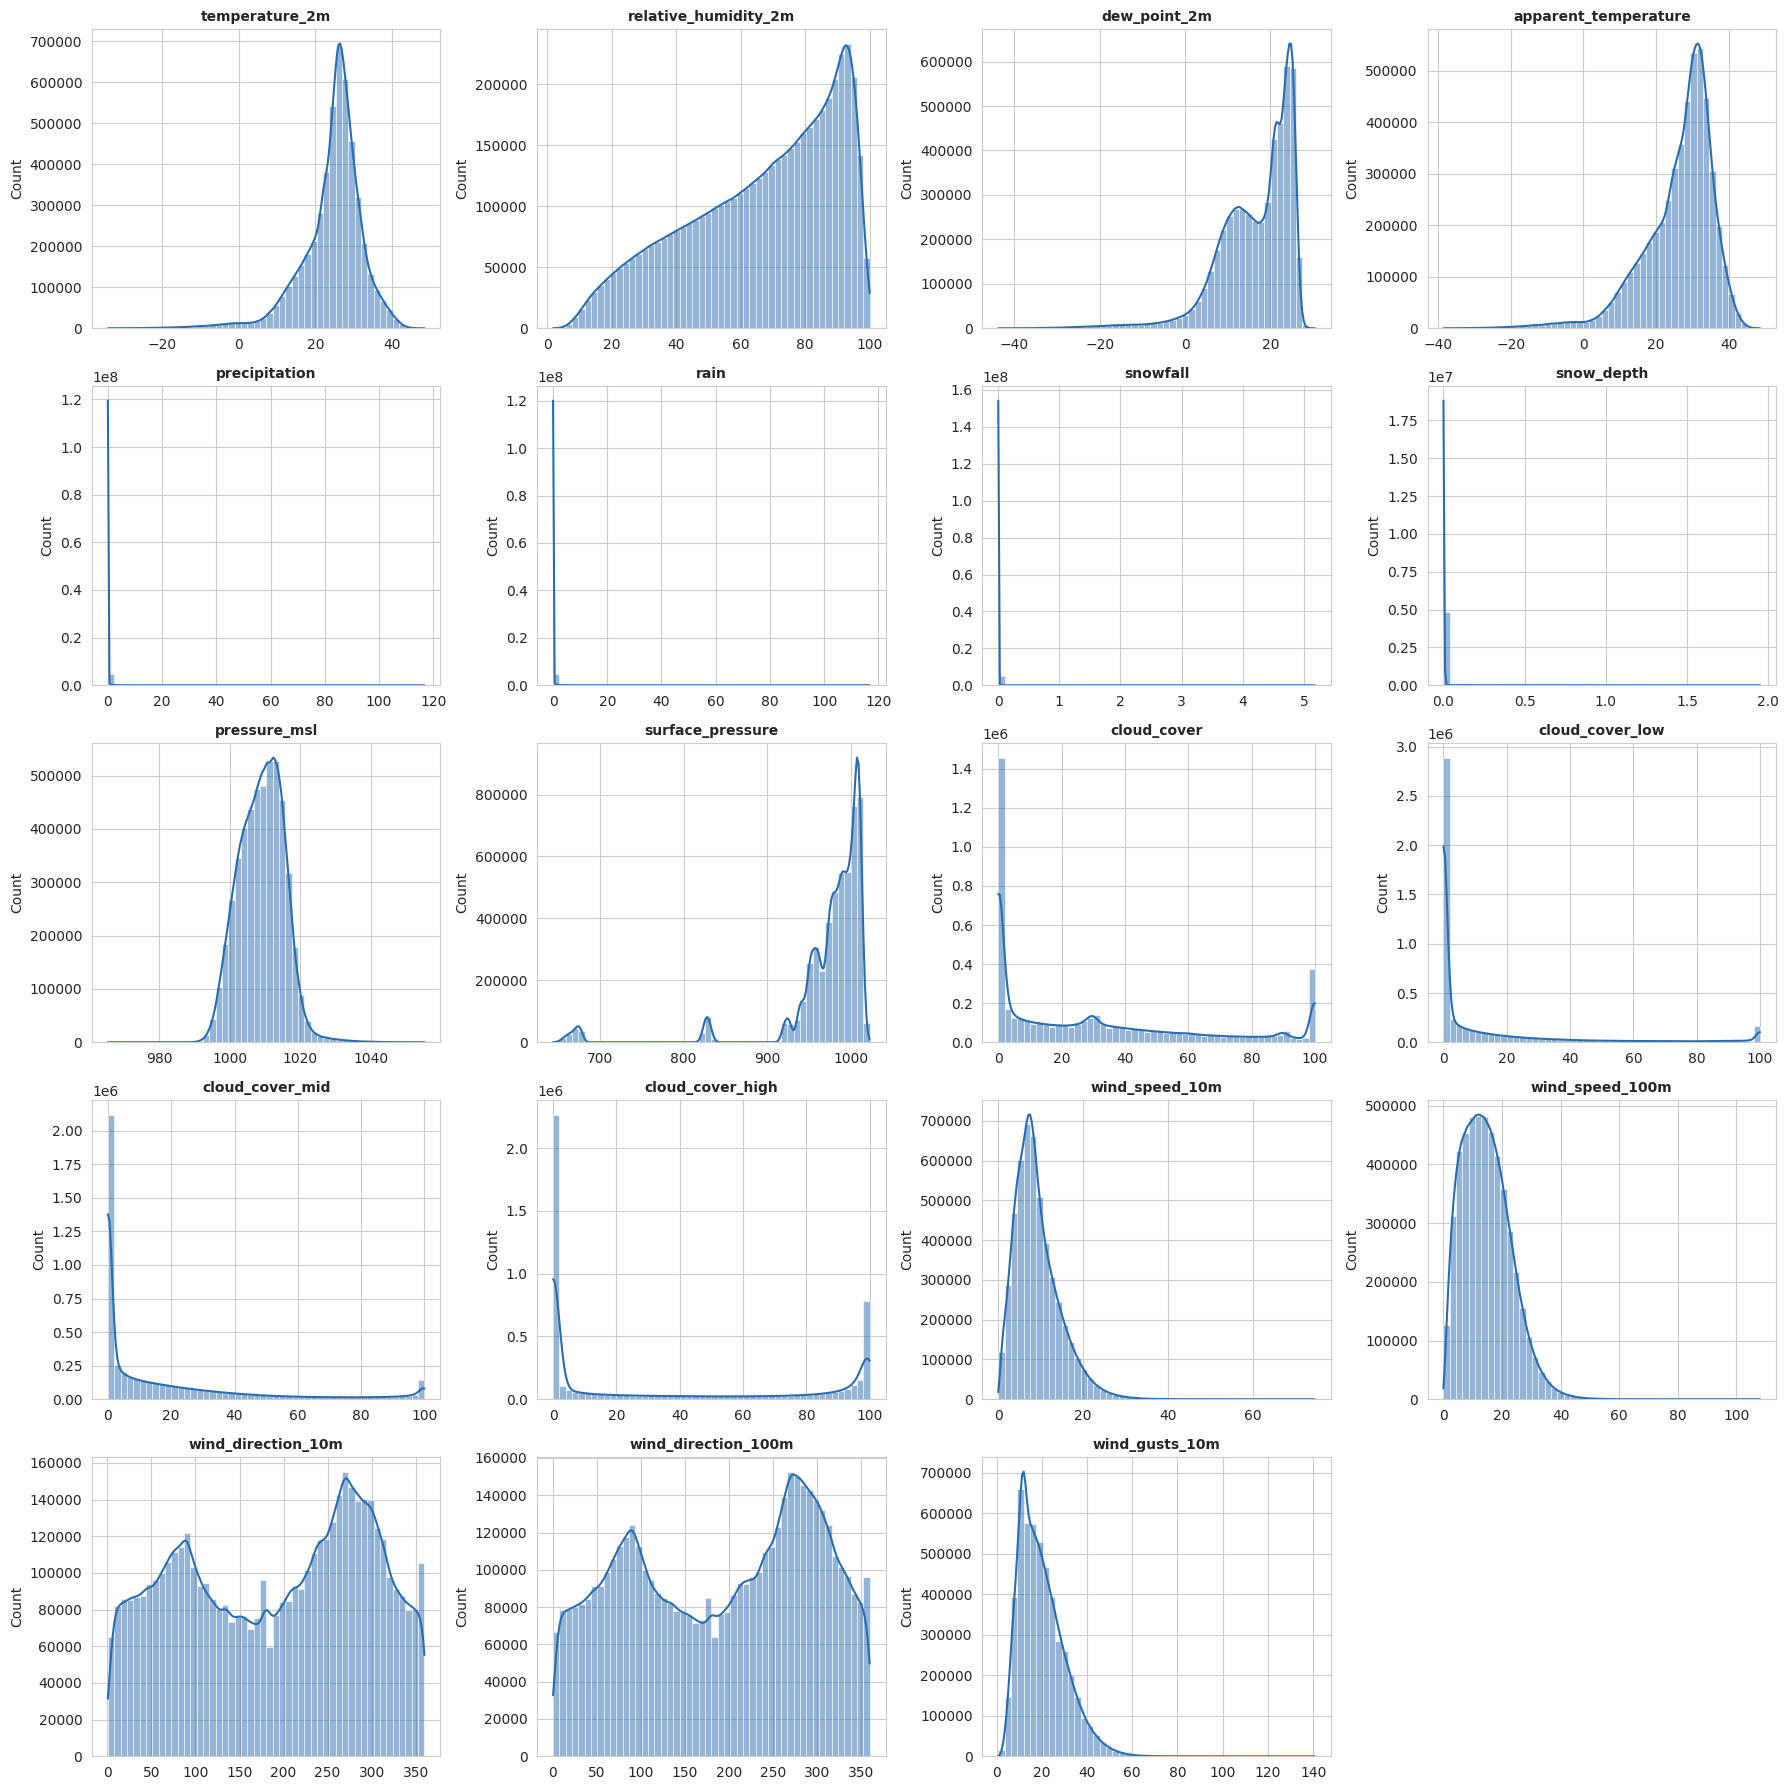

In [11]:
fig, axes = plt.subplots(5, 4, figsize=(18, 18))
axes = axes.flatten()
for i, col in enumerate(HOURLY_COLS):
    sns.histplot(hourly[col].dropna(), bins=50, ax=axes[i], color="#2b6cb0", kde=True)
    axes[i].set_title(col, fontsize=10)
    axes[i].set_xlabel("")
for j in range(len(HOURLY_COLS), len(axes)):
    axes[j].axis("off")
plt.tight_layout()
plt.show()

## 4. Outlier detection (IQR method) — how much of each variable is 'extreme'

In [12]:
def iqr_outlier_pct(s):
    s = s.dropna()
    q1, q3 = s.quantile([0.25, 0.75])
    iqr = q3 - q1
    lo, hi = q1 - 1.5 * iqr, q3 + 1.5 * iqr
    return ((s < lo) | (s > hi)).mean() * 100

outlier_summary = pd.Series({c: iqr_outlier_pct(hourly[c]) for c in HOURLY_COLS}, name="outlier_pct").round(2)
outlier_summary = outlier_summary.sort_values(ascending=False).to_frame()
outlier_summary

,outlier_pct
precipitation,16.59
rain,16.37
cloud_cover_low,14.00
cloud_cover_mid,9.20
surface_pressure,5.00
temperature_2m,4.82
apparent_temperature,3.07
wind_speed_10m,2.77
snow_depth,2.42
dew_point_2m,1.97


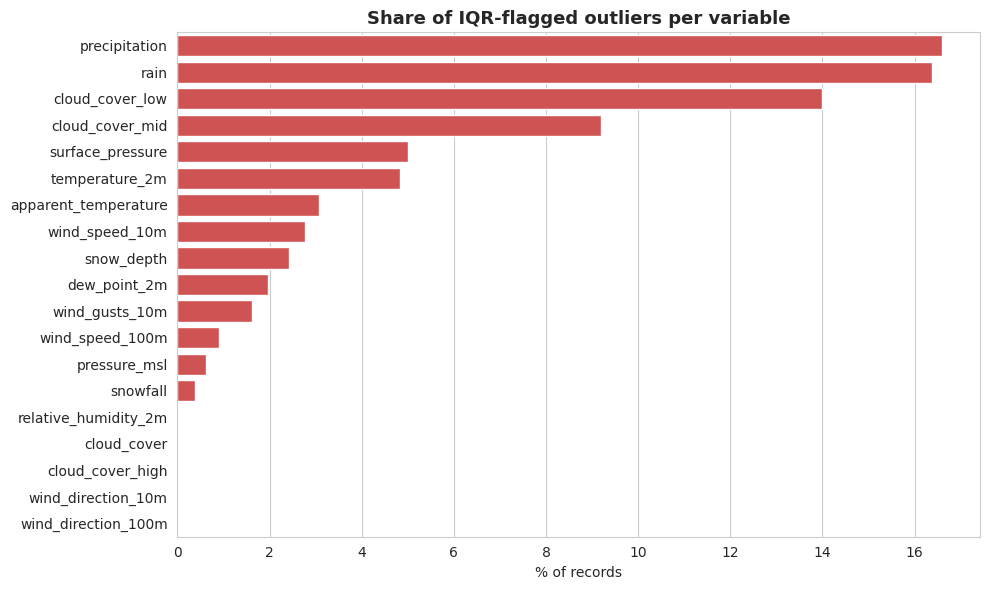

In [13]:
fig, ax = plt.subplots(figsize=(10, 6))
sns.barplot(data=outlier_summary.reset_index(), y="index", x="outlier_pct", color="#e53e3e", ax=ax)
ax.set_title("Share of IQR-flagged outliers per variable")
ax.set_xlabel("% of records"); ax.set_ylabel("")
plt.tight_layout()
plt.show()

## 5. Boxplots — key variables by climate-contrast cities
Comparing a desert city, a coastal city, a hill-station and a metro makes distribution differences immediately obvious for a non-technical audience.

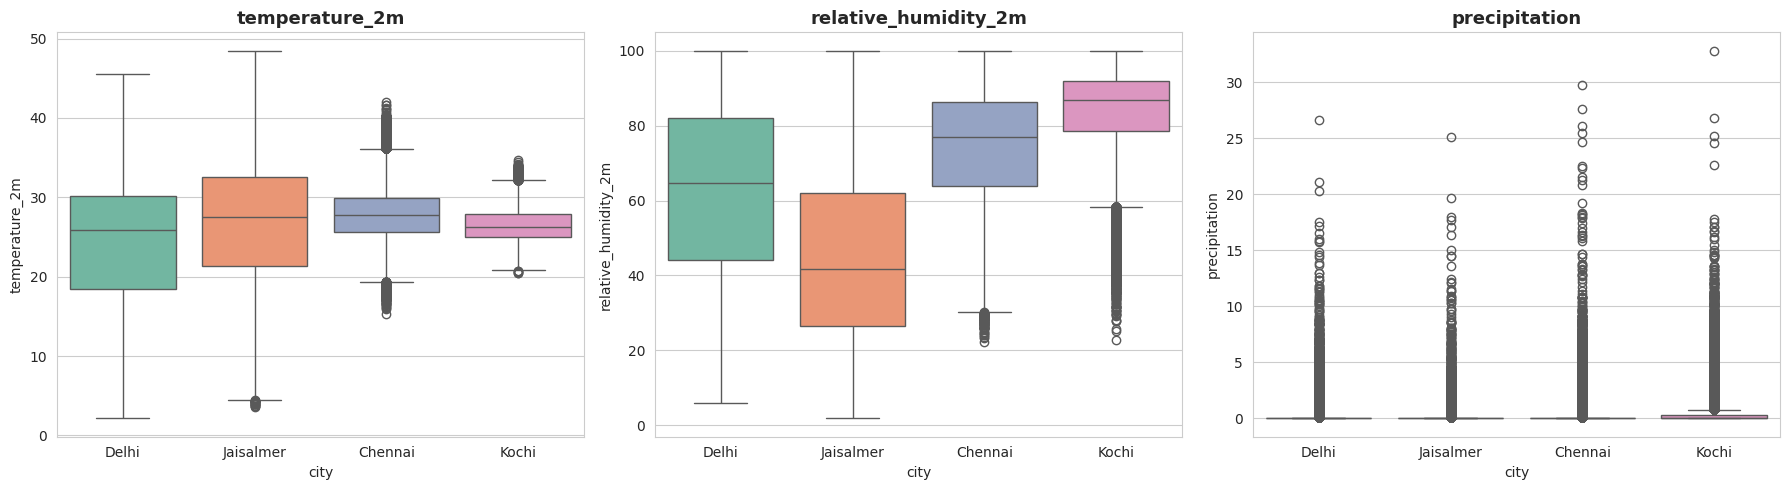

In [14]:
CONTRAST_CITIES = [c for c in ["Jaisalmer", "Kochi", "Shimla", "Chennai", "Delhi"] if c in hourly["city"].unique()]
plot_df = hourly[hourly["city"].isin(CONTRAST_CITIES)]

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for ax, col in zip(axes, ["temperature_2m", "relative_humidity_2m", "precipitation"]):
    sns.boxplot(data=plot_df, x="city", y=col, ax=ax, palette="Set2")
    ax.set_title(col)
plt.tight_layout()
plt.show()

## 6. Summary

In [15]:
print("STATISTICAL & DISTRIBUTION ANALYSIS -- SUMMARY")
print("=" * 55)
print("Variables likely needing transform before modeling:",
      list(shape_stats[shape_stats["likely_needs_transform"]].index))
print("\nMost outlier-prone variables (top 5):")
print(outlier_summary.head(5))

STATISTICAL & DISTRIBUTION ANALYSIS -- SUMMARY
Variables likely needing transform before modeling: ['temperature_2m', 'dew_point_2m', 'apparent_temperature', 'precipitation', 'rain', 'snowfall', 'snow_depth', 'surface_pressure', 'cloud_cover_low', 'cloud_cover_mid', 'wind_speed_10m']

Most outlier-prone variables (top 5):
                  outlier_pct
precipitation           16.59
rain                    16.37
cloud_cover_low         14.00
cloud_cover_mid          9.20
surface_pressure         5.00
